In [1]:
%pwd
%load_ext autoreload
%autoreload 2

In [2]:
from scripts.run_experiments import run_experiment
from scripts.experiment_utils import generate_experiments

In [3]:
base_config = {
    # Experiment
    "experiment": "flower_curve_lucky_one",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "s1_synthetic",
    "batch_size": 64,
    "rotation": "random",
    "translation": "random",
    "n_times": 10000,
    "embedding_dim": 10,
    "radius": 2,
    "noise_var": 0.001,
    "n_wiggles": 5,
    "geodesic_distortion_amp": 0.1,
    "geodesic_distortion_func": "wiggles",  # Accepted values "wiggles" or "bump"

    # Model
    'model_type': 'EuclideanVAE',
    "data_dim": 10,
    'latent_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [100, 100, 100],
    'decoder_widths': [100, 100, 100],

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 20,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 0,  # Max feature dimension topological loss
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "compute_true_curv": True,
    "compute_learned_curv": True,
    "compute_rec_curv": True,
    "quadric_dim": 1,
    "n_plot_points": 1000,
    "n_points_emp_curv": 1000,
    "n_points_pullback_curv": 1000, 
    "k": 110,
    "smoothing": False,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}

param_grid = {
    "wiggling_dim": [4] * 11,
    "embedding_dim": [10] * 11,
    "alpha": [1] * 2 + [1, 1, 0] * 3,
    "gamma": [0] * 2 + [1, 100, 1] * 3,
    "geodesic_distortion_amp": [0.3] * 11,
    "dim_topo_loss": [0] + [1] + [0] * 3 + [1] * 3 + [2] * 3,
}

# param_grid = {
#     "alpha": [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0] * 3,
#     "gamma": [0.0, 1.0, 1.0, 100.0, 100.0, 1.0, 1.0] * 3,
#     "dim_topo_loss": ["_", 0, 1, 0, 1, 0, 1] * 3,
#     "geodesic_distortion_amp": [0.1] * 7 + [0.3] * 14,
#     "noise_var": [0.001] * 14 + [0.01] * 7,
# }

all_configs = generate_experiments(base_config, param_grid)


Running exp00_flower_curve_lucky_one. 
Description: wiggling_dim=4, embedding_dim=10, alpha=1, gamma=0, geodesic_distortion_amp=0.3, dim_topo_loss=0
--------------------------------------------------------------------------------------


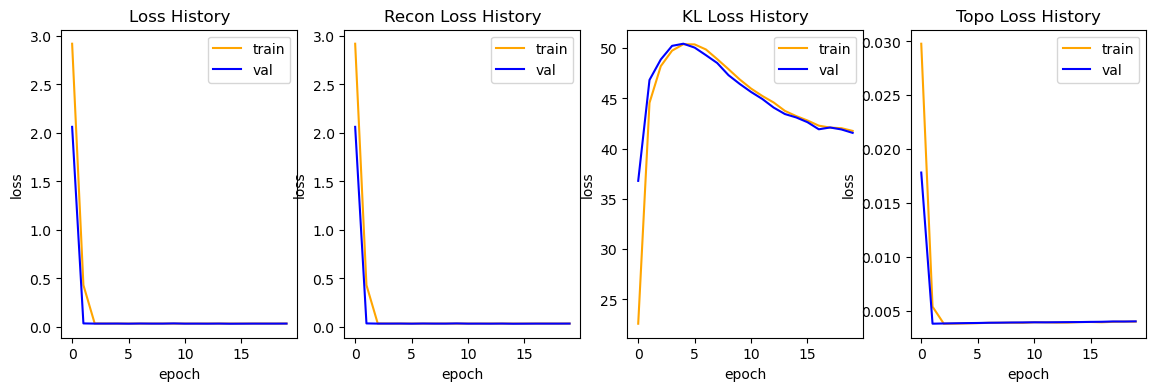

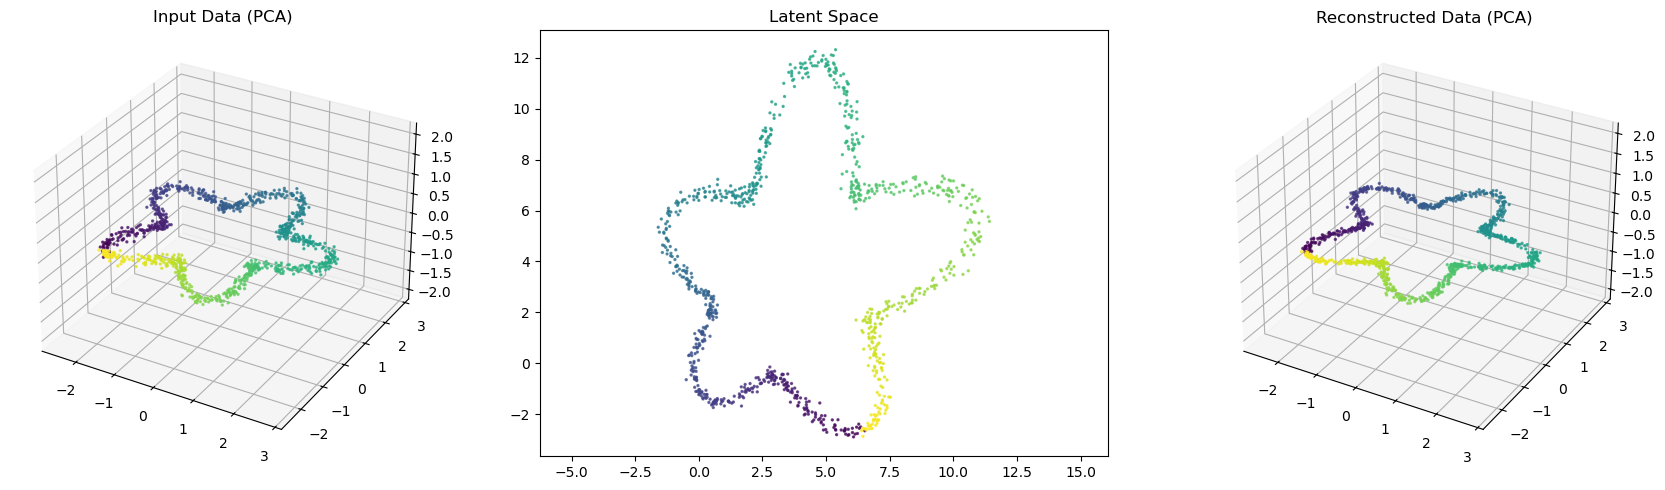

Estimating 1D curvature: 100%|██████████| 1000/1000 [00:00<00:00, 1201.55it/s]


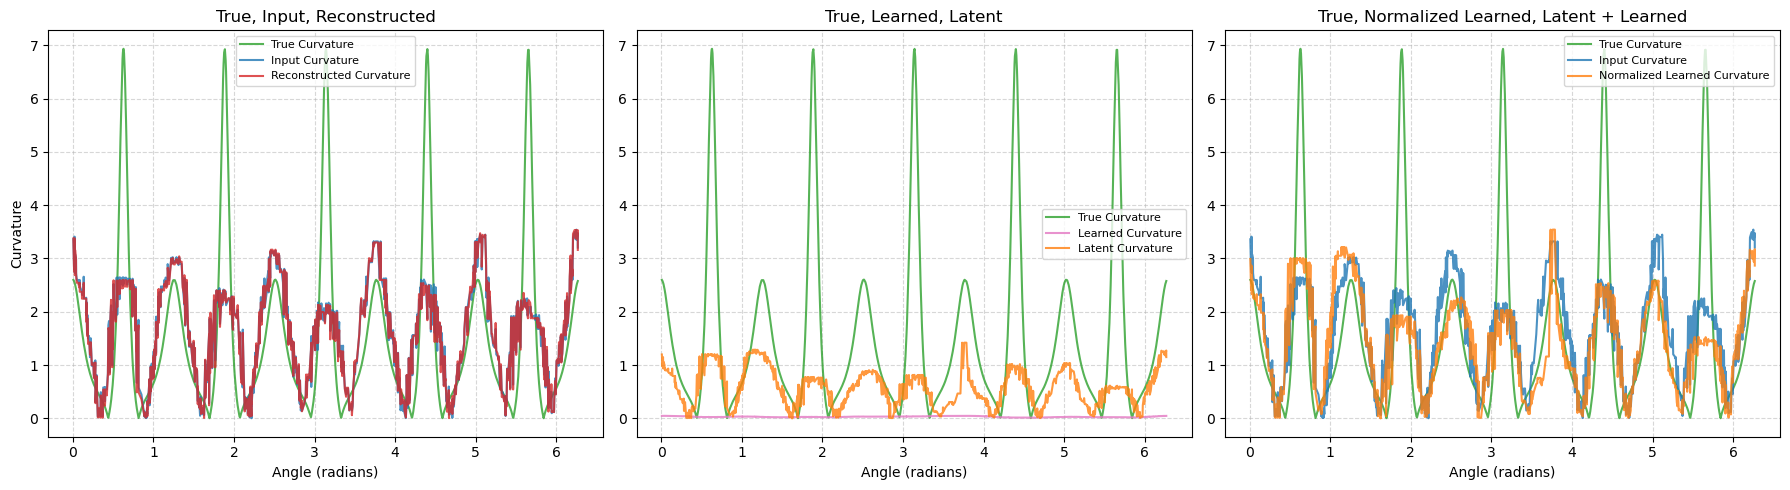

<Figure size 1800x1000 with 0 Axes>

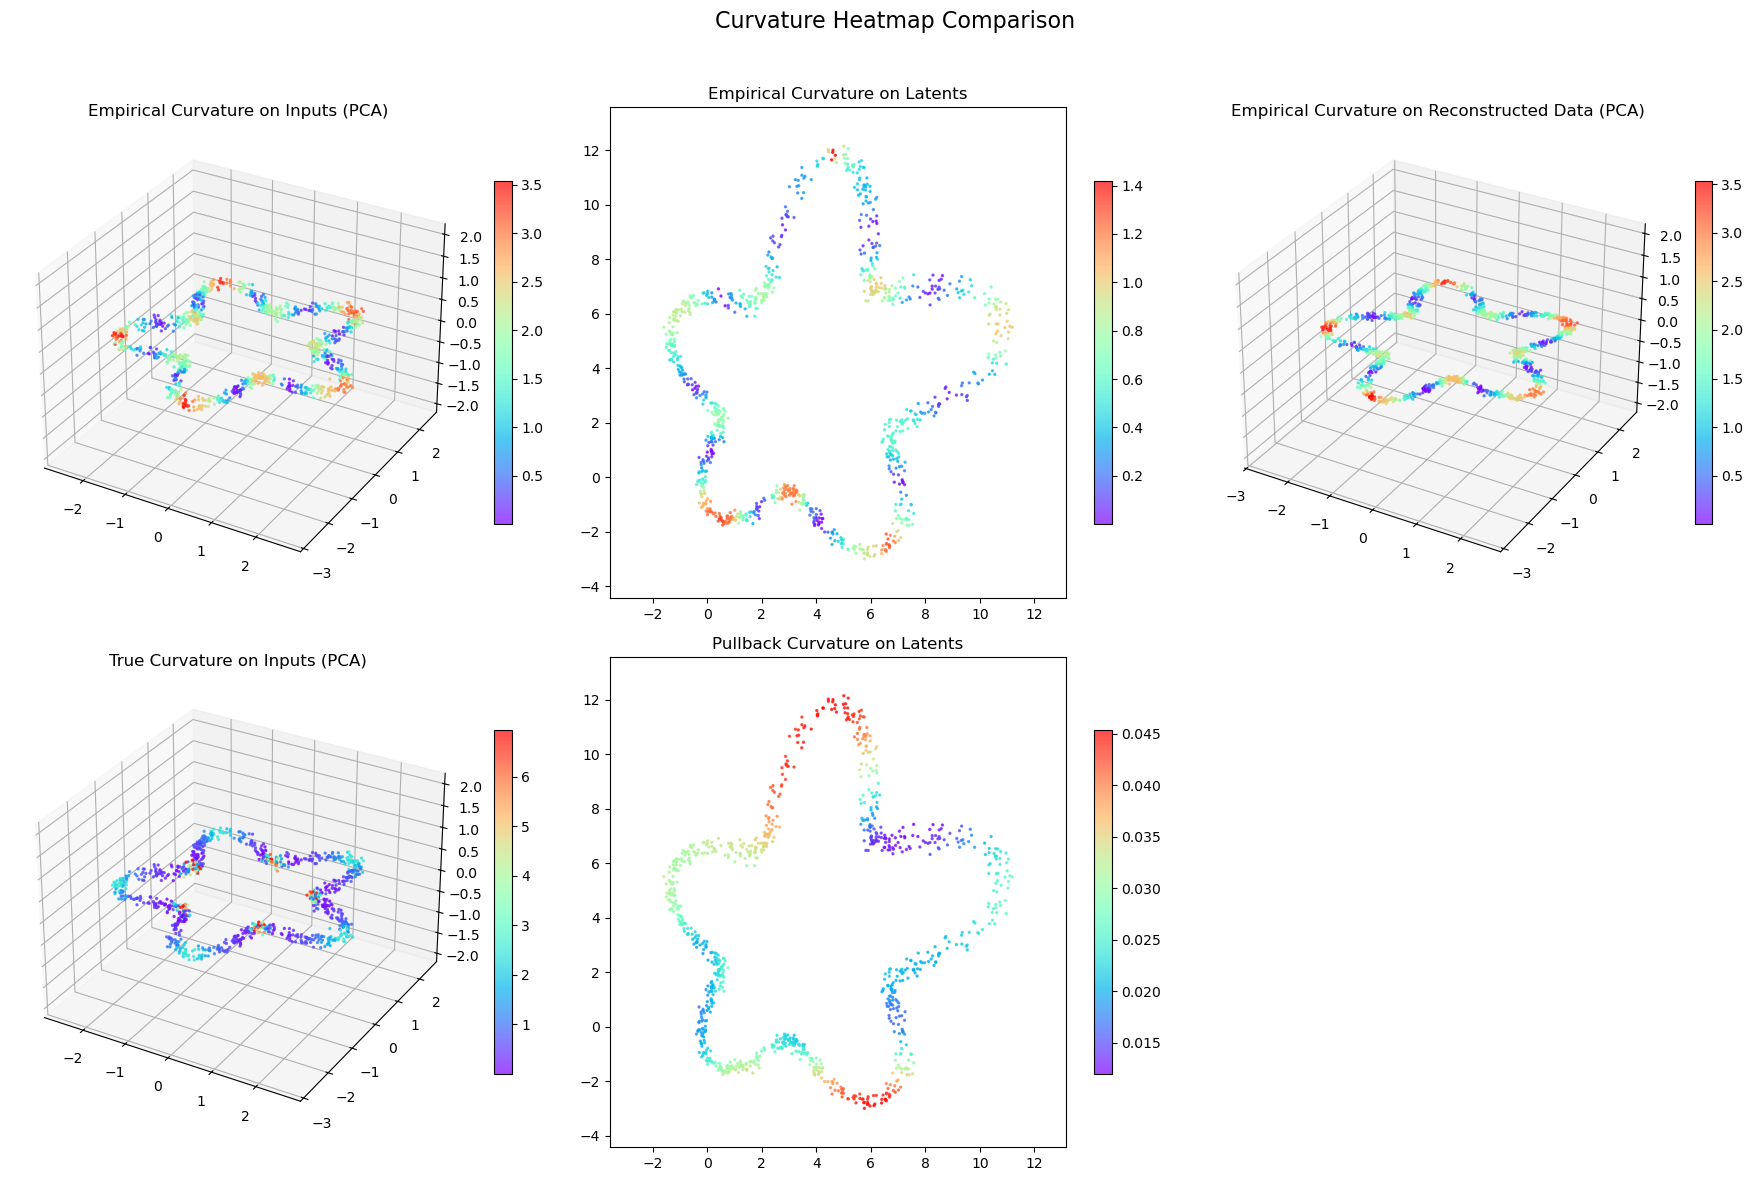

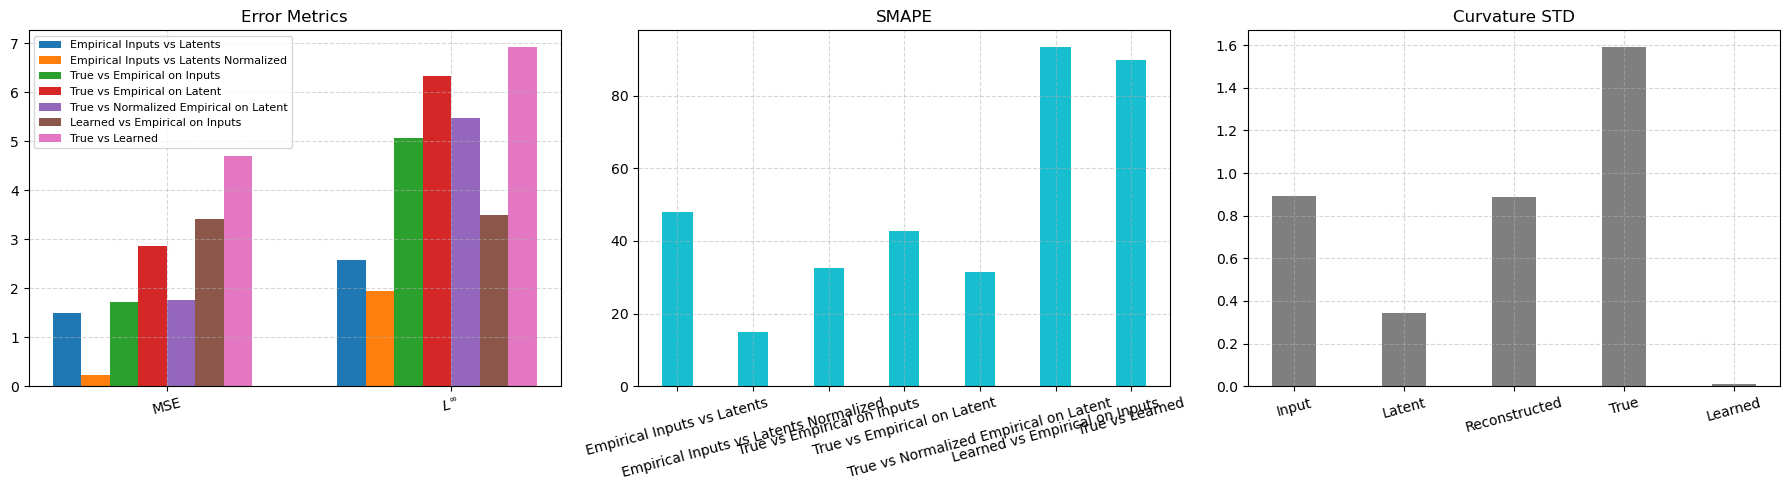

Execution time exp00_flower_curve_lucky_one: 89.2047 seconds

Running exp01_flower_curve_lucky_one. 
Description: wiggling_dim=4, embedding_dim=10, alpha=1, gamma=0, geodesic_distortion_amp=0.3, dim_topo_loss=1
--------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [4]:
run_experiment(all_configs=all_configs)